## 1. Overview
## 2. Import Libraries
## 3. Load Dataset
## 4. Data Cleaning
## 5. Feature Engineering
## 6. Visualizations
## 7. Insights
## 8. Conclusion

## 1. overview

## Titanic Dataset - Mini EDA Dashboard

## This project performs Exploratory Data Analysis (EDA) on the Titanic dataset using Python libraries such as Pandas, Seaborn, and Matplotlib.

## The goal is to clean the data, create useful features, visualize patterns, and extract meaningful insights.

## Import Libraries

In [4]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt


## Load Dataset

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Data Cleaning 

## Check Missing Values

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Fill Missing Age

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

## Fill Embarked

In [8]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## Drop Cabin

In [10]:
if 'Cabin' in df.columns:
    df = df.drop(columns =['Cabin'])


# Data Cleaning INsight 

### Missing value in Age and Embarked were handled using mean and mode imputation . The Cabin column was removed due to excessive missing value.

# Feature Engineering

## Creating FamilySize

In [12]:
df['FamilySize'] = df['SibSp'] + df['Parch']

## Create AgeGroup

In [13]:
bins = [0,12,18,35,60,100]
labels = ['Child','Teen','Young Adult','Adult','Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins , labels=labels)

## Feature Engineering Insight

### New features such as FamilySize and AgeGroup were created to better analyze passenger survival patterns.

# Visualizations

## Histogram( Age Distribution)

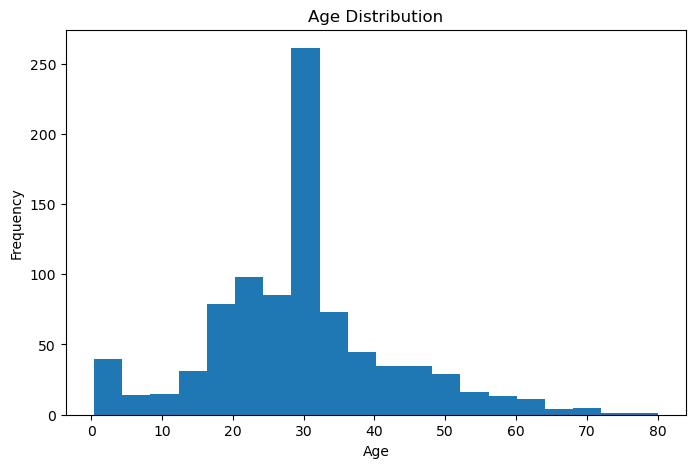

In [14]:
plt.figure(figsize=(8,5))

df['Age'].plot(kind = 'hist',bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

## Most passengers were between 20 and 40 years old.

# Bar Plot (Survival b Gender)

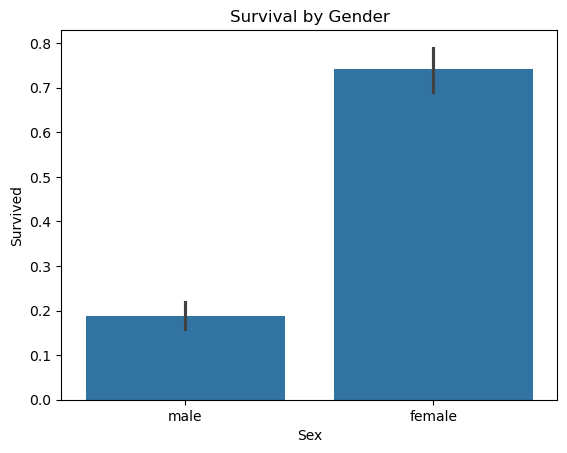

In [16]:
sns .barplot(x='Sex',y='Survived',data=df)

plt.title("Survival by Gender")

plt.show()

## Female passengers had significantly higher survival rates than males.

# Boxplot (Fare by Passenger Class)

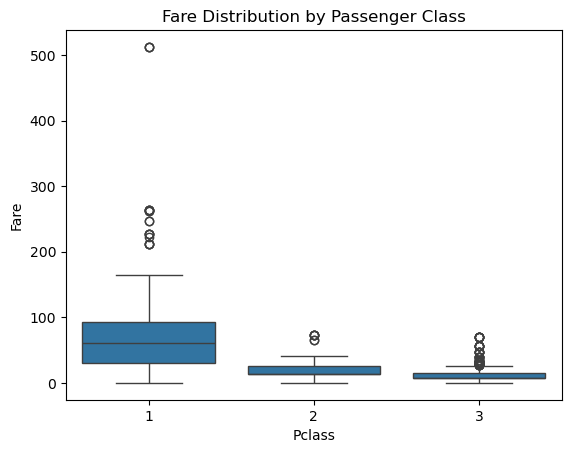

In [17]:
sns.boxplot(x='Pclass',y='Fare',data=df)

plt.title("Fare Distribution by Passenger Class")

plt.show()

## Boxplot shows:

### distribution
### spread
### outliers

## 1st class passengers generally paid higher fares than 2nd and 3rd class passengers.

# Scatterplot ( Age vs Fare)

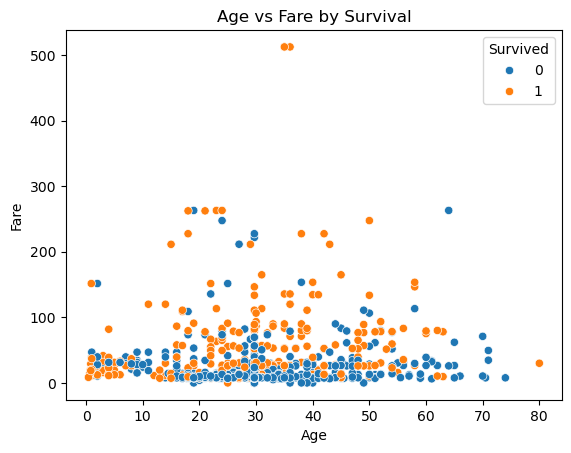

In [18]:
sns.scatterplot(x='Age',y='Fare',hue='Survived',data=df)

plt.title("Age vs Fare by Survival")

plt.show()

## Passengers who paid higher fares had slightly better survival chances.

# Heatmap(Correlation)

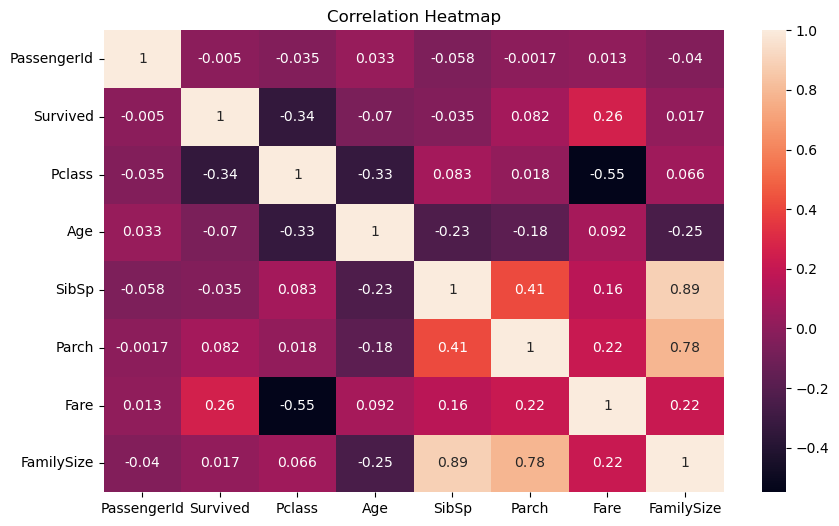

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

## The heatmap shows relationships between numerical features such as Fare, Age, and Survival.

# Survival by Family Size

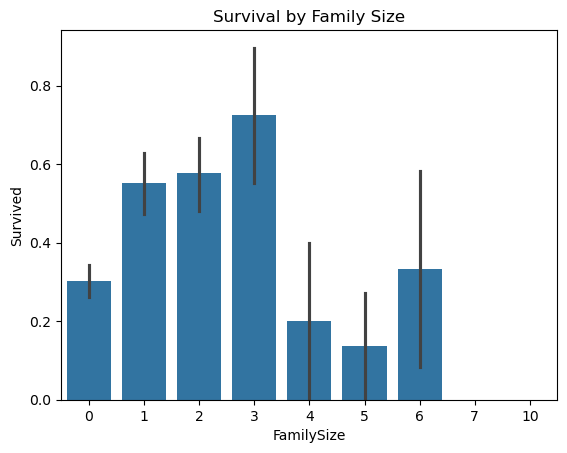

In [21]:
sns.barplot(x='FamilySize',y='Survived',data=df)

plt.title("Survival by Family Size")

plt.show()

## Passengers traveling with small families had better survival rates.

# Final Insights

## - Female passengers survived more than males.
## - Passenger class strongly influenced survival chances.
## - Children had better survival rates.
## - Family size affected survival probability.
## - Higher fare passengers showed better survival chances.
## - Data visualization helped identify important hidden patterns.

# Conclusion

## This dashboard demonstrates how Exploratory Data Analysis (EDA) can be used to clean data, create meaningful visualizations, and discover valuable insights from real-world datasets.